In [2]:
import os, sys

# Make sure we're in the project root
os.chdir("/Users/danesh/Documents/GitHub/trueQ")

# Ensure project root is on sys.path
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

from config import *
from cer import *

In [3]:
dep_strength = 0.0121405*4
t_gate_rotation = 0.180213
h_gate_rotation = 0.1
cnot_gate_rotation = 0.073675

In [4]:
noisy_sim_dep = (
            tq.Simulator().add_overrotation(single_sys=dep_strength, match=match_clifford)
               .add_overrotation(single_sys= t_gate_rotation, match=match_t)
               .add_overrotation(single_sys=h_gate_rotation, match=match_h)
               .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot)
        )

In [5]:
def noisy_paulis(sim: tq.Simulator):
    noisy_gates = {}
    for gate in paulis:
        noisy_gates[gate] = tq.Gate(sim.operator(tq.Circuit([{0: gate}])).mat())
    return noisy_gates

def noisy_dihedral(sim: tq.Simulator):
    noisy_gates = {}
    for gate in easy_gates:
        noisy_gates[gate] = tq.Gate(sim.operator(tq.Circuit([{0: gate}])).mat())
    return noisy_gates

def noise(noisy_gates):
    noise = {}
    for gate in noisy_gates:
        noise[gate] = noisy_gates[gate]@gate.adj
    return noise

def avg_noise(noise):
    superop = {}
    for gate in noise:
        superop[gate] = tqm.Superop.from_unitary(tq.Simulator().operator(tq.Circuit([{0: noise[gate]}])).mat()).ptm
    
    return tqm.Superop.from_ptm(sum(superop.values())/len(superop))

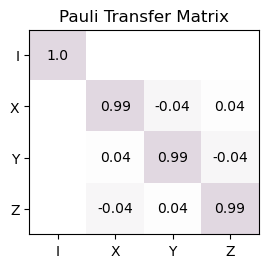

In [18]:
noise_superop = avg_noise(noise(noisy_paulis(noisy_sim_dep)))
noise_superop.plot_ptm()

In [7]:
pauli_gate_independent_noise = {pauli: noise_superop@tqm.Superop.from_unitary(pauli.mat) for pauli in paulis}

In [8]:
def gate_replace(gate):
    return pauli_gate_independent_noise[gate]

In [9]:
noisy_sim_gate_indep =  (tq.Simulator().add_gate_replace(gate_replace, match = tqs.GateMatch(paulis)) 
                            .add_overrotation(single_sys=t_gate_rotation, match=match_t)
                            .add_overrotation(single_sys=h_gate_rotation, match=match_h)
                            .add_overrotation(single_sys = cnot_gate_rotation, multi_sys=cnot_gate_rotation, match=match_cnot))

In [29]:
cb_circs = tq.make_cb(cycles=tq.Cycle({0:tq.Gate.h}), n_random_cycles= [2,4,6,8,12], n_circuits= 2000, n_decays=4)

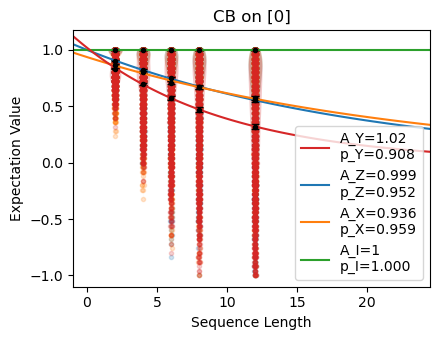

In [30]:
noisy_sim_dep.run(cb_circs)

cb_circs.plot.raw()

In [31]:
cb_circs.fit()

CB Cycle Benchmarking,"Paulis (0,) : Gate.h Key: cycles: (Cycle((0,): Gate.h),) labels: (0,) protocol: CB twirl: Paulis on [0]"
${e}_{I}$ The probability of the subscripted error acting on the specified labels.,"9.5e-01 (1.1e-03) 0.9547767037445691, 0.0011068269085315948"
${e}_{F}$ The probability of an error acting on the specified labels during a dressed cycle of interest.,"4.5e-02 (1.1e-03) 0.04522329625543087, 0.0011068269085315948"
${p}_{Z}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.5e-01 (1.6e-03) 0.951948765812659, 0.0016185887297979144"
${p}_{Y}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.1e-01 (3.1e-03) 0.9082124870749139, 0.003113579491430734"
${p}_{X}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.6e-01 (1.5e-03) 0.9589455620907037, 0.001544856931792843"
${p}_{I}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (2.3e-19) 1.0, 2.293194379882355e-19"
${A}_{Z}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (8.0e-03) 0.9994370851062454, 0.007983791592508935"
${A}_{Y}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.6e-02) 1.0187439033268486, 0.015690075876891633"
${A}_{X}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.4e-01 (7.5e-03) 0.9359128546589804, 0.007514020552522789"
${A}_{I}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.9e-18) 1.0, 1.8918853634029427e-18"


         (/opt/miniconda3/envs/new_qiskit/lib/python3.12/site-packages/trueq/simulation/simulator.py:273)


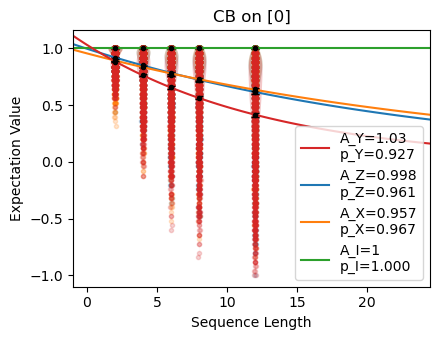

In [32]:
noisy_sim_gate_indep.run(cb_circs)

cb_circs.plot.raw()

In [33]:
cb_circs.fit()

CB Cycle Benchmarking,"Paulis (0,) : Gate.h Key: cycles: (Cycle((0,): Gate.h),) labels: (0,) protocol: CB twirl: Paulis on [0]"
${e}_{I}$ The probability of the subscripted error acting on the specified labels.,"9.6e-01 (7.7e-04) 0.9636140372435711, 0.0007709870217199679"
${e}_{F}$ The probability of an error acting on the specified labels during a dressed cycle of interest.,"3.6e-02 (7.7e-04) 0.03638596275642891, 0.0007709870217199679"
${p}_{Z}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.6e-01 (1.2e-03) 0.960687873853802, 0.0011801902431217237"
${p}_{Y}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.3e-01 (2.1e-03) 0.9272006904175581, 0.002113000437955912"
${p}_{X}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.7e-01 (1.1e-03) 0.9665675847029241, 0.001129350251766885"
${p}_{I}$ Decay parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.6e-19) 1.0, 1.6344893657148416e-19"
${A}_{Z}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (5.8e-03) 0.9977096063440694, 0.0057708624534865225"
${A}_{Y}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.1e-02) 1.0314404700674467, 0.010679167649662522"
${A}_{X}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"9.6e-01 (5.6e-03) 0.9565991328430642, 0.005608239478545994"
${A}_{I}$ SPAM parameter of the exponential decay $Ap^m$ for the given Pauli term.,"1.0e+00 (1.3e-18) 1.0, 1.3484537267147441e-18"


In [10]:
def random_cb_circuit_no_meas(hard_gate: tq.Gate, easy_gate_set: list, depth: int):

    if hard_gate == Gate.cx:
        lst = []
        for i in range(depth):
            t1 = random.choice(easy_gate_set)
            t2 = random.choice(easy_gate_set)
            cycle = [tq.Cycle({0:t1, 1:t2}), tq.Cycle({(0,1):hard_gate}, marker=1)]
            lst.append(cycle[0])
            lst.append(cycle[1])
        t1 = random.choice(easy_gate_set)
        t2 = random.choice(easy_gate_set)
        final_cycle = tq.Cycle({0:t1, 1:t2})
        lst.append(final_cycle)
        circ = tq.Circuit(lst)
        return circ

    else:
        lst = []
        for i in range(depth):
            t = random.choice(easy_gate_set)
            cycle = [tq.Cycle({0:t}), tq.Cycle({0:hard_gate}, marker=1)]
            lst.append(cycle[0])
            lst.append(cycle[1])
        t = random.choice(easy_gate_set)
        final_cycle = tq.Cycle({0:t})
        lst.append(final_cycle)
        circ = tq.Circuit(lst)
        return circ

In [12]:
def check_off_diagonal_terms_ptm(circuit: tq.Circuit, n_randomizations: int, simulator: tq.Simulator):
    
    rc_circs = tq.randomly_compile(circuit=circuit, n_compilations=n_randomizations)

    ptms = [(tqm.Superop.from_unitary(noise(noisy_paulis(noisy_sim_dep))[list(rc_circ[-1].gates.values())[0]].mat).adj).ptm@tqm.Superop.from_unitary(simulator.operator(rc_circ).mat()).ptm  for rc_circ in rc_circs]
    avg_ptm = sum(ptms) / len(ptms)

    return tqm.Superop.from_ptm(avg_ptm)

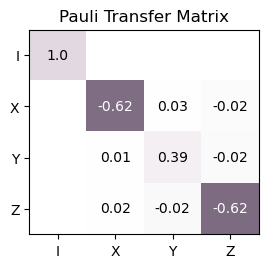

In [17]:
check_off_diagonal_terms_ptm(random_cb_circuit_no_meas(tq.Gate.h, paulis, 10), 10000, noisy_sim_dep).plot_ptm()